In [1]:
import os
import numpy as np
import cvxpy as cp
import mosek

import utils

SAVE = True
PREFIX = './results/sem'

# Check restuls dir exists and create
if not os.path.exists(PREFIX):
    os.makedirs(PREFIX)

## Load and plot data

Shape of: X: (122, 1214)  -  Y: (2, 1214)  -  data: (124, 1214)
(Min, Max) values of: X: (0.000, 1.000)  - Y: (-0.998, 1.000)  -  data: (-0.998, 1.000)
Mean value of: X: 0.416  -  Y: 0.001  -  data: 0.409


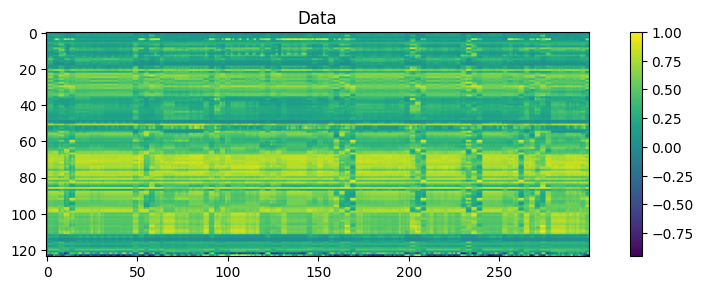

In [2]:
Data = utils.load_accoustic_data()
N, M = Data.shape

## Undirected SEM

In [3]:
# Estimate A
lamb0 = np.sqrt(np.log(N)/M)

Mults = [1, 250, 500, 700, 800, 1e3]
Undir_sem = []
for mult in Mults:
    lamb = mult*lamb0

    A = cp.Variable((N,N), symmetric=True)
    obj = cp.sum_squares(A@Data - Data) + lamb*cp.sum(A)
    constr = [A >= 0, A[np.eye(N, dtype=bool)] == 0]

    prob = cp.Problem(cp.Minimize(obj), constr)
    obj = prob.solve(solver='MOSEK', verbose=False)

    print(f'Lamb (mult): {lamb:.4f} ({mult})  - status: {prob.status}')

    A_est = A.value
    A_est /= np.max(np.abs(A_est))

    Undir_sem.append(A_est)

Lamb (mult): 0.0630 (1)  - status: optimal
Lamb (mult): 15.7531 (250)  - status: optimal
Lamb (mult): 31.5063 (500)  - status: optimal
Lamb (mult): 44.1088 (700)  - status: optimal
Lamb (mult): 50.4100 (800)  - status: optimal
Lamb (mult): 63.0125 (1000.0)  - status: optimal


### Threshold = 0.01

- Lamb: 0.06301252173882214  -  Prop. edges above threshold: 0.076
- Lamb: 15.753130434705536  -  Prop. edges above threshold: 0.072
- Lamb: 31.506260869411072  -  Prop. edges above threshold: 0.069
- Lamb: 44.1087652171755  -  Prop. edges above threshold: 0.066
- Lamb: 50.410017391057714  -  Prop. edges above threshold: 0.064
- Lamb: 63.012521738822144  -  Prop. edges above threshold: 0.060


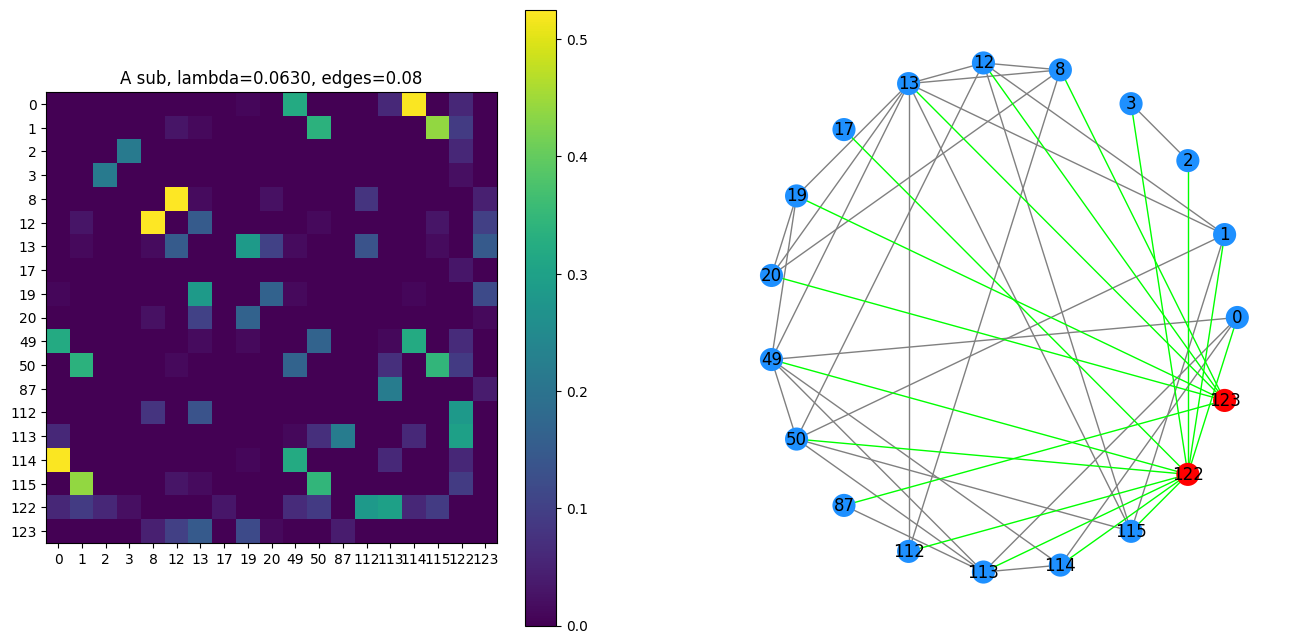

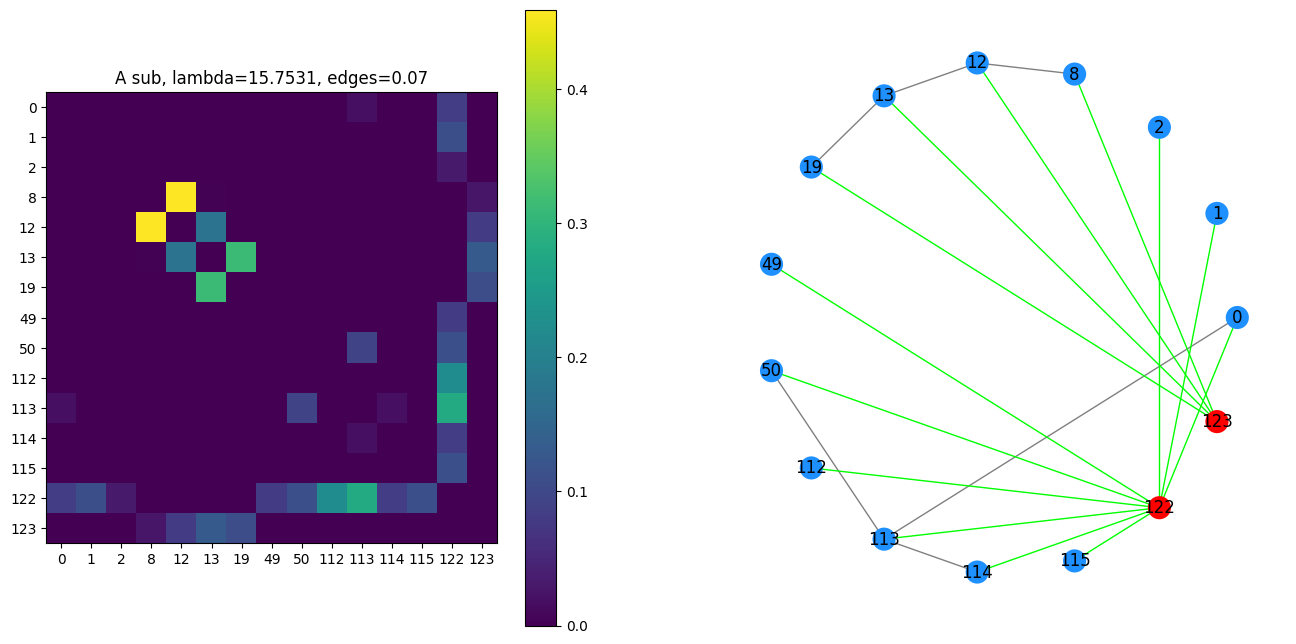

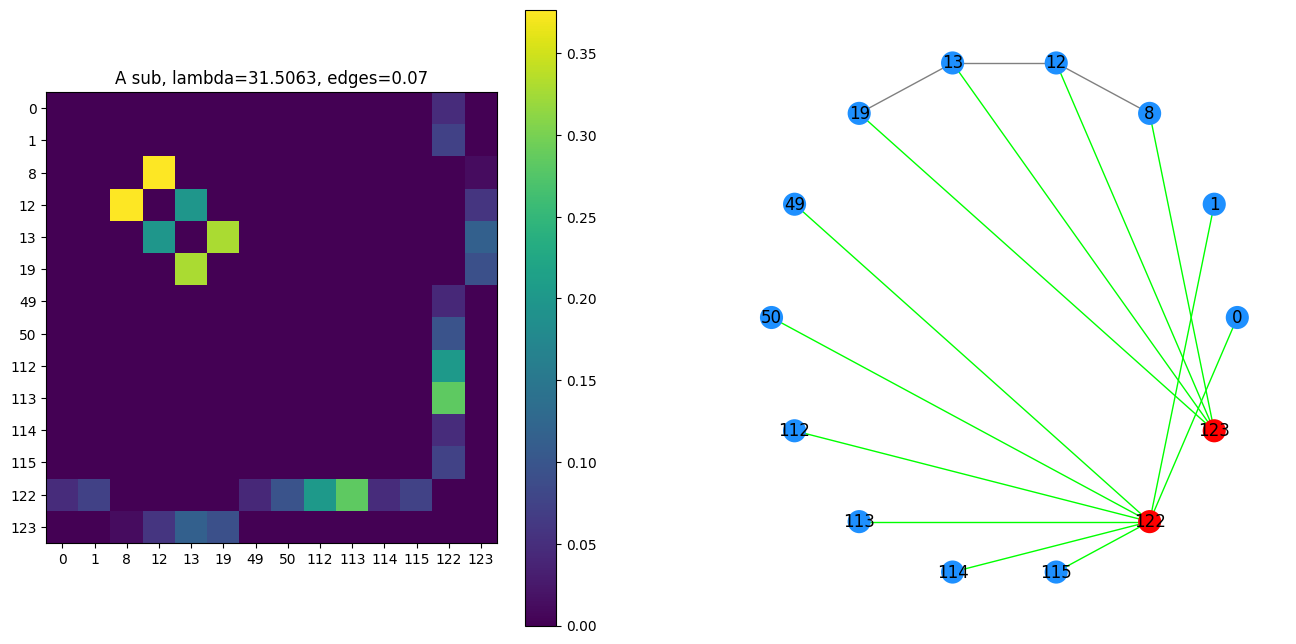

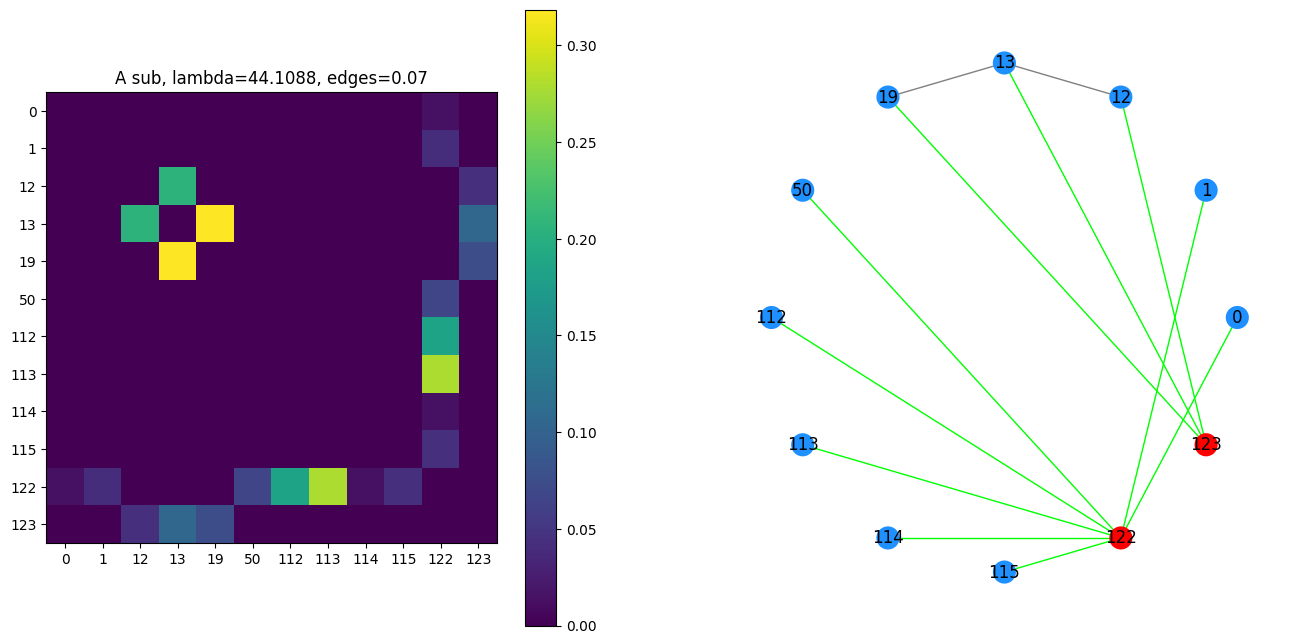

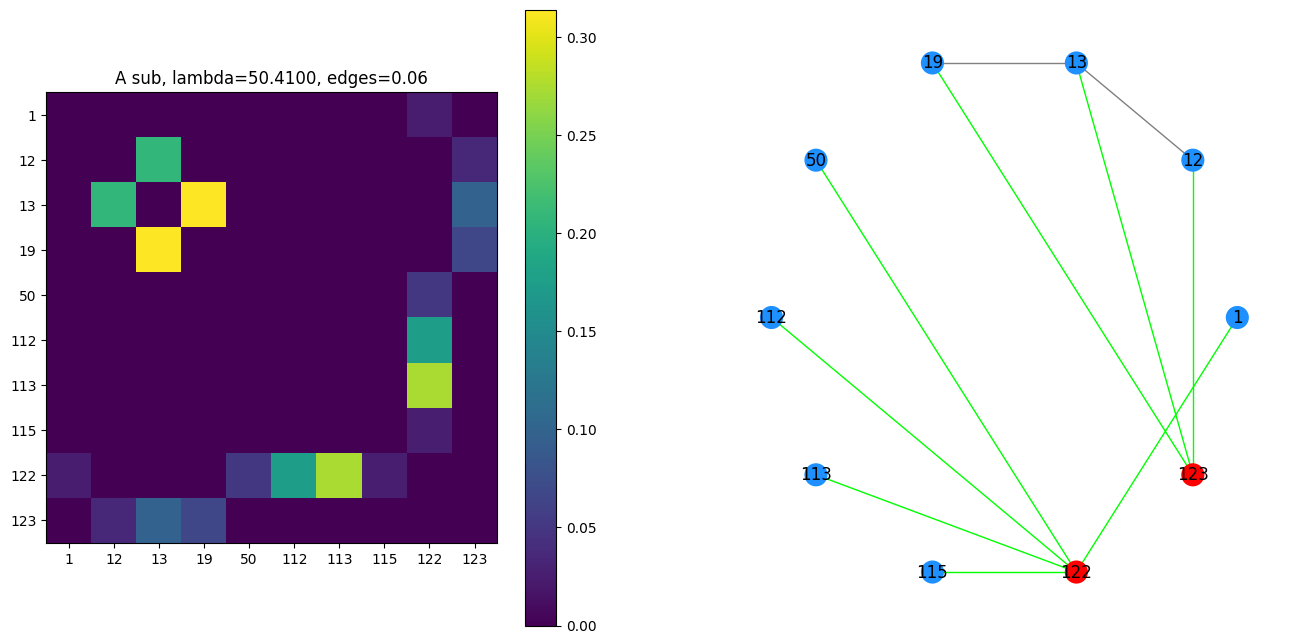

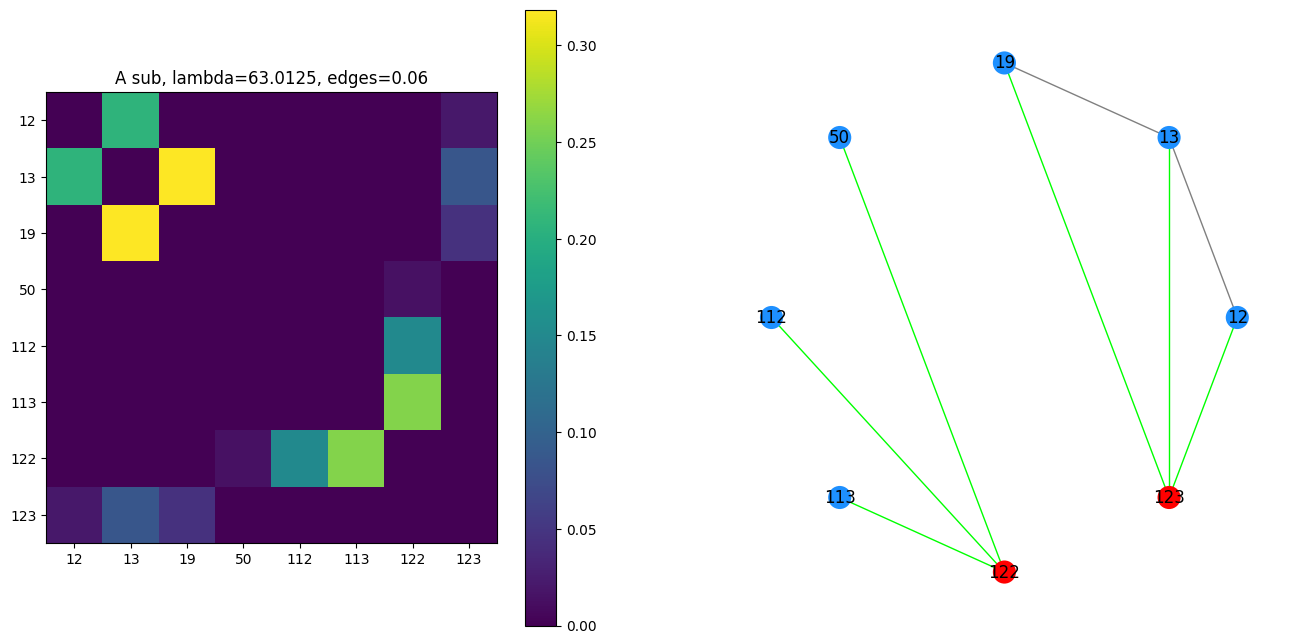

In [4]:
# Plot A
th = 0.01
for i, A_est in enumerate(Undir_sem):
    mult = Mults[i]
    file_name = f'{PREFIX}/sem_und{mult}_{th}'
    # utils.save_plot_graph(A_est, th, mult*lamb0, file_name=file_name, save=SAVE)
    utils.save_plot_subgraph(A_est, th, mult*lamb0, file_name=file_name, save=SAVE)

### Threshold = 0.05

- Lamb: 0.06301252173882214  -  Prop. edges above threshold: 0.045
- Lamb: 15.753130434705536  -  Prop. edges above threshold: 0.044
- Lamb: 31.506260869411072  -  Prop. edges above threshold: 0.042
- Lamb: 44.1087652171755  -  Prop. edges above threshold: 0.042
- Lamb: 50.410017391057714  -  Prop. edges above threshold: 0.043
- Lamb: 63.012521738822144  -  Prop. edges above threshold: 0.043


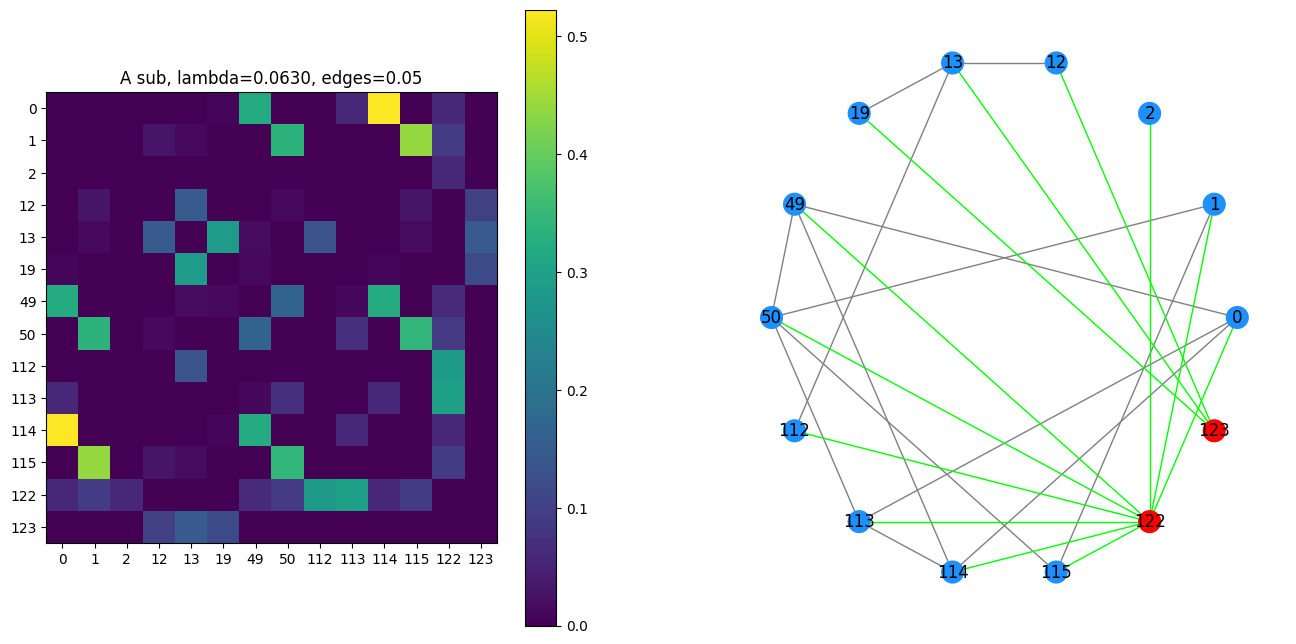

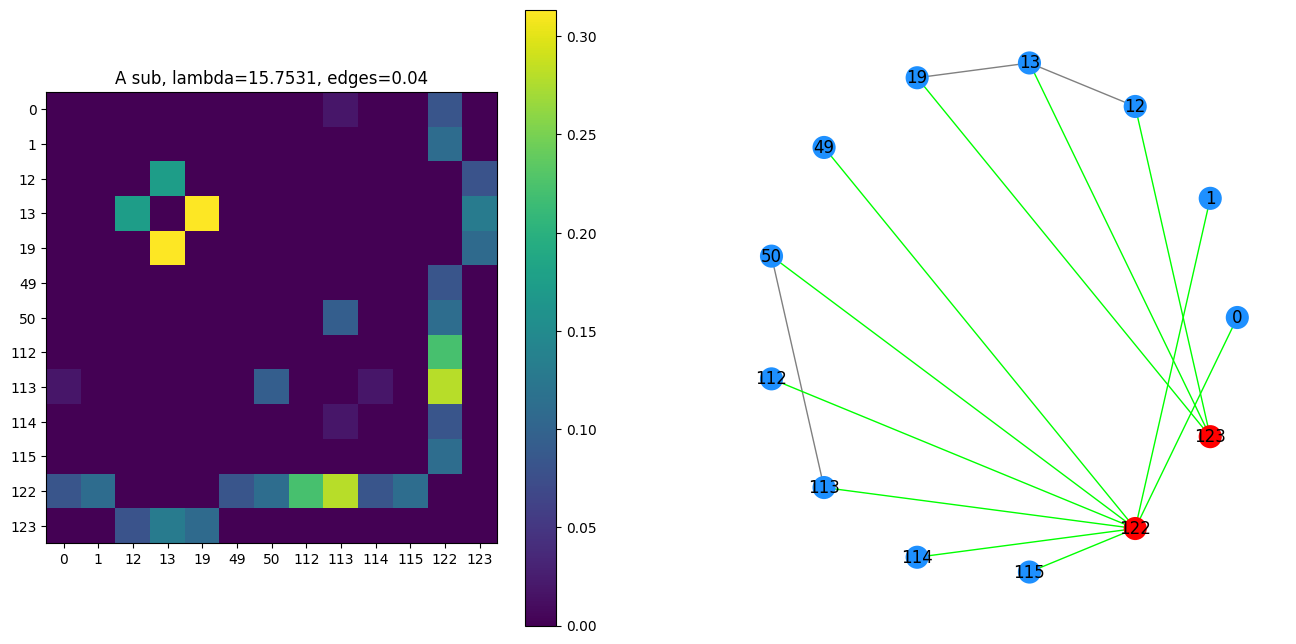

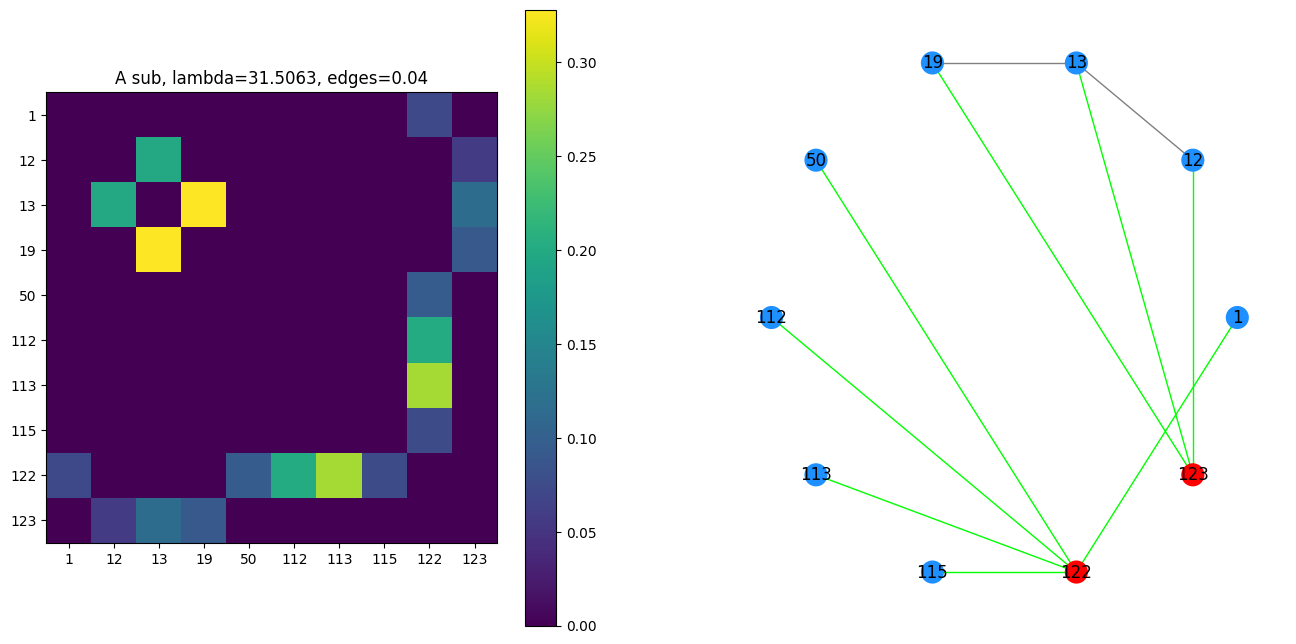

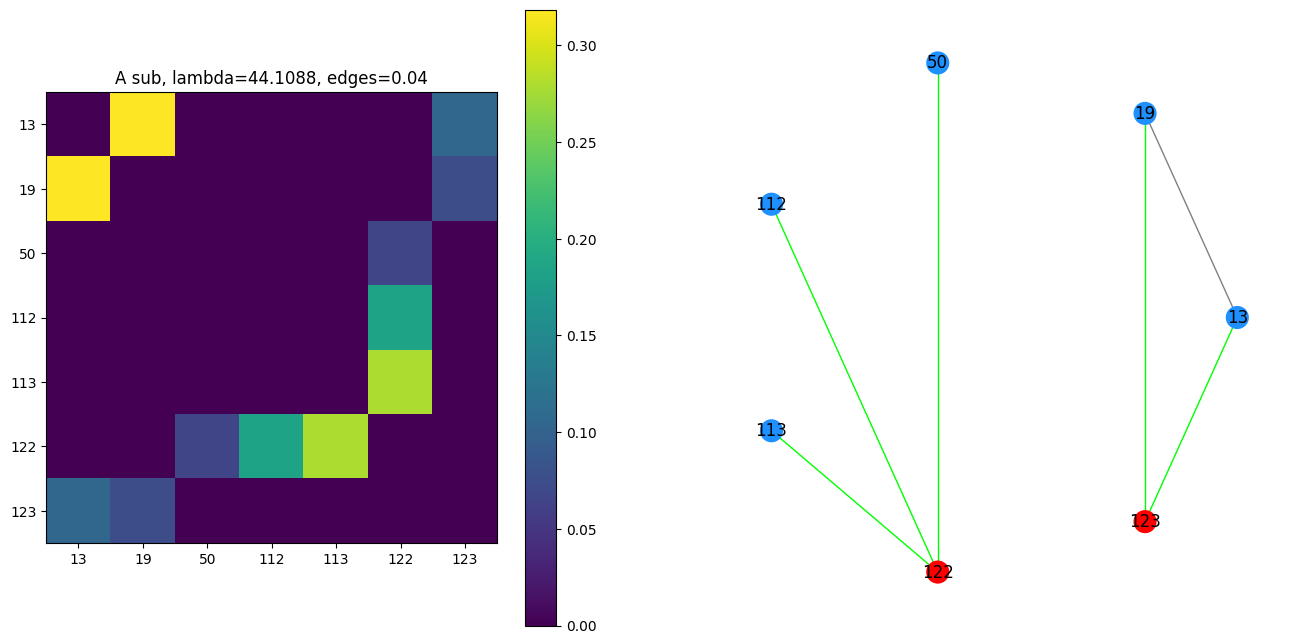

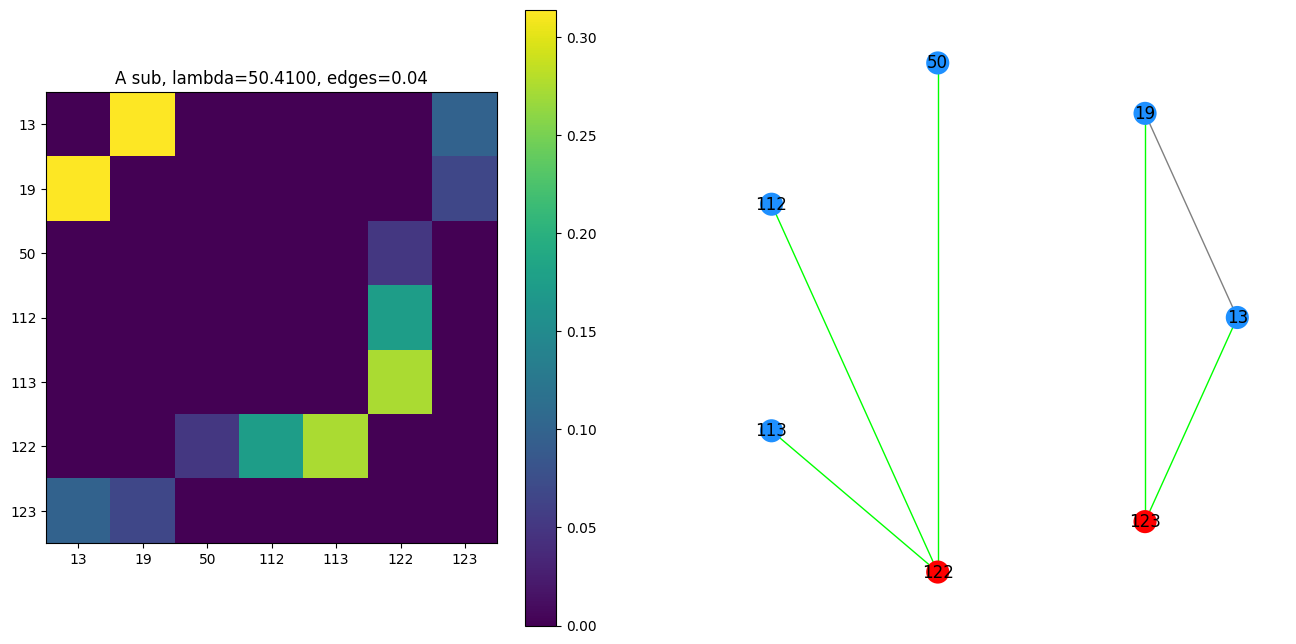

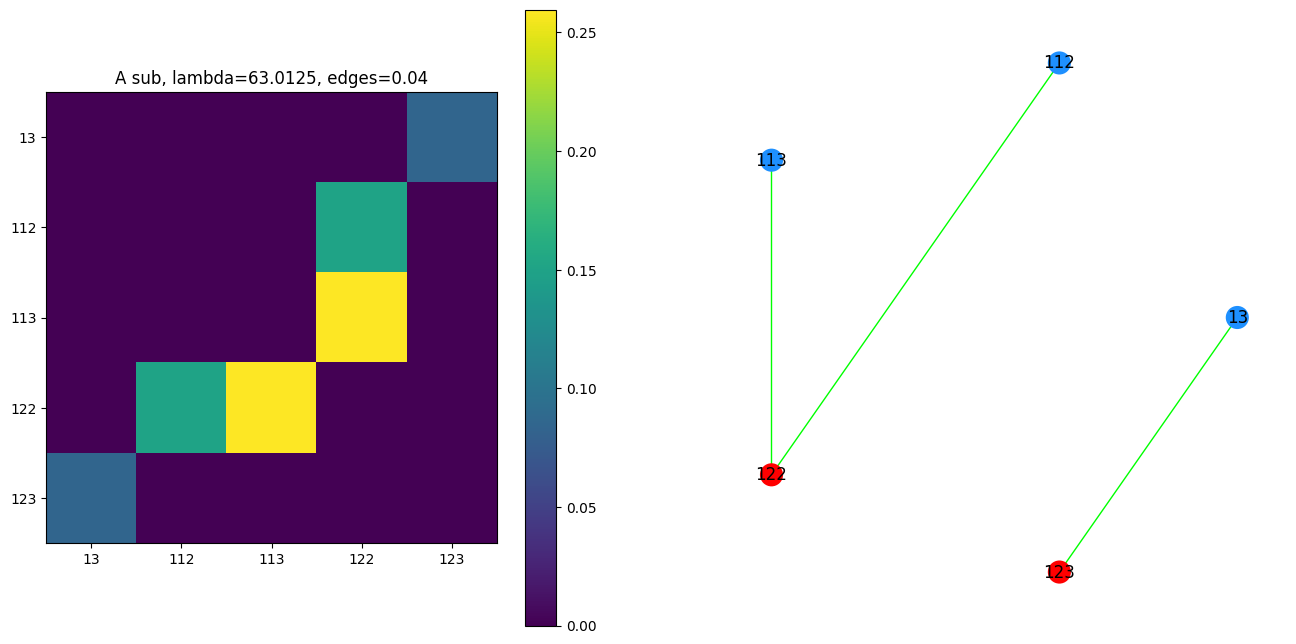

In [5]:
# Plot A
th = 0.05
for i, A_est in enumerate(Undir_sem):
    mult = Mults[i]
    file_name = f'{PREFIX}/sem_und{mult}_{th}'
    # utils.save_plot_graph(A_est, th, mult*lamb0, file_name=file_name, save=SAVE)
    utils.save_plot_subgraph(A_est, th, mult*lamb0, file_name=file_name)

## Directed SEM

In [6]:
# Estimate A
lamb0 = np.sqrt(np.log(N)/M)

Mults = [25, 250, 500, 700, 800, 1e3]
Dir_sem = []
for mult in Mults:
    lamb = mult*lamb0
    
    A = cp.Variable((N,N), symmetric=False)
    obj = cp.sum_squares(A@Data - Data) + lamb*cp.sum(A)
    constr = [A >= 0, A[np.eye(N, dtype=bool)] == 0]

    prob = cp.Problem(cp.Minimize(obj), constr)
    obj = prob.solve(solver='MOSEK', verbose=False)

    print(f'Lamb (mult): {lamb:.4f} ({mult})  - status: {prob.status}')
    
    A_est = A.value
    A_est /= np.max(np.abs(A_est))

    Dir_sem.append(A_est)

Lamb (mult): 1.5753 (25)  - status: optimal
Lamb (mult): 15.7531 (250)  - status: optimal
Lamb (mult): 31.5063 (500)  - status: optimal
Lamb (mult): 44.1088 (700)  - status: optimal
Lamb (mult): 50.4100 (800)  - status: optimal
Lamb (mult): 63.0125 (1000.0)  - status: optimal


### Threshold = 0.01

- Lamb: 1.5753130434705536  -  Prop. edges above threshold: 0.066
- Lamb: 15.753130434705536  -  Prop. edges above threshold: 0.049
- Lamb: 31.506260869411072  -  Prop. edges above threshold: 0.040
- Lamb: 44.1087652171755  -  Prop. edges above threshold: 0.036
- Lamb: 50.410017391057714  -  Prop. edges above threshold: 0.034
- Lamb: 63.012521738822144  -  Prop. edges above threshold: 0.030


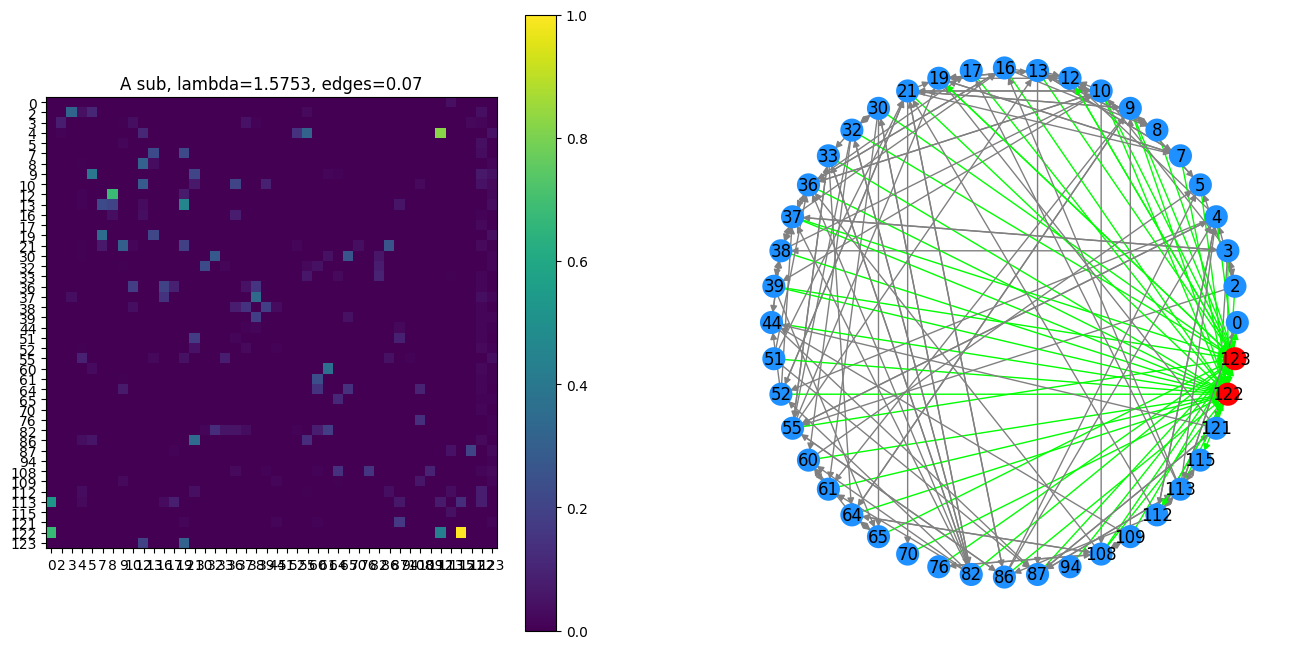

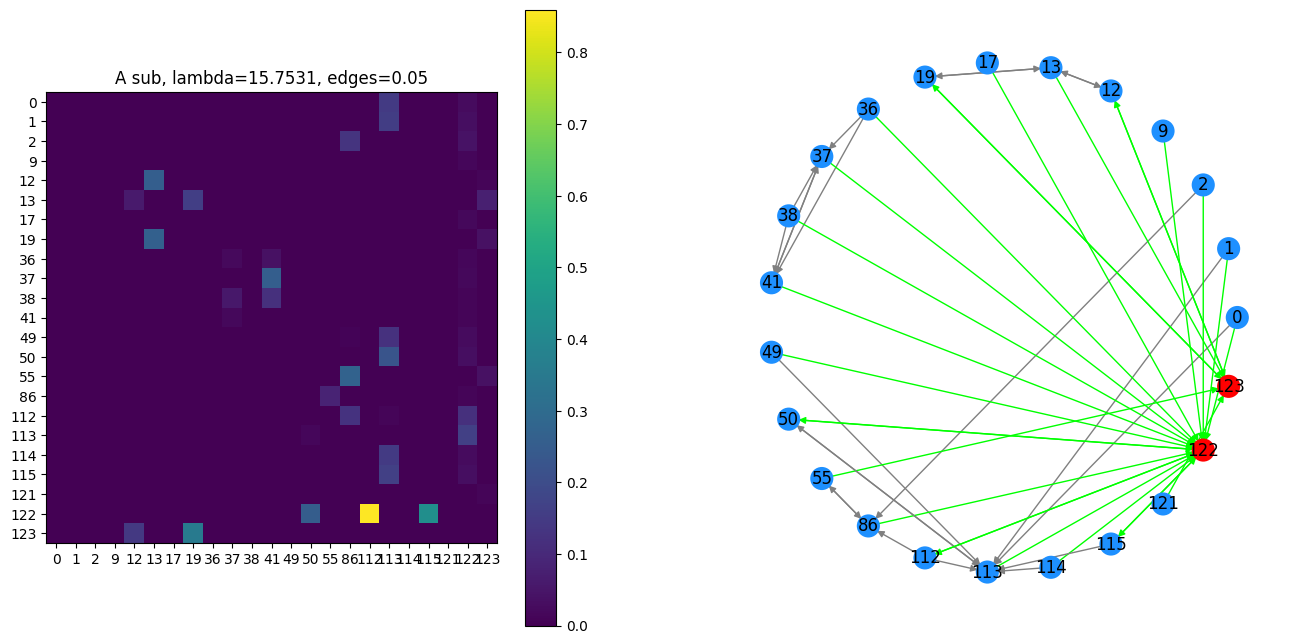

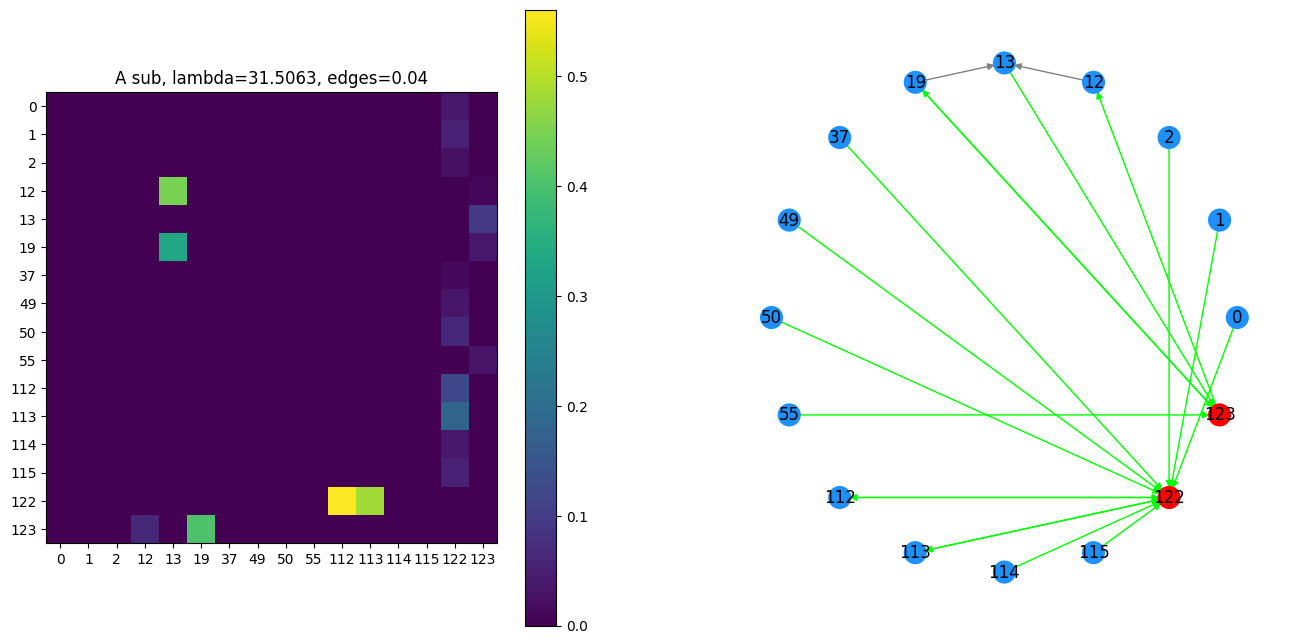

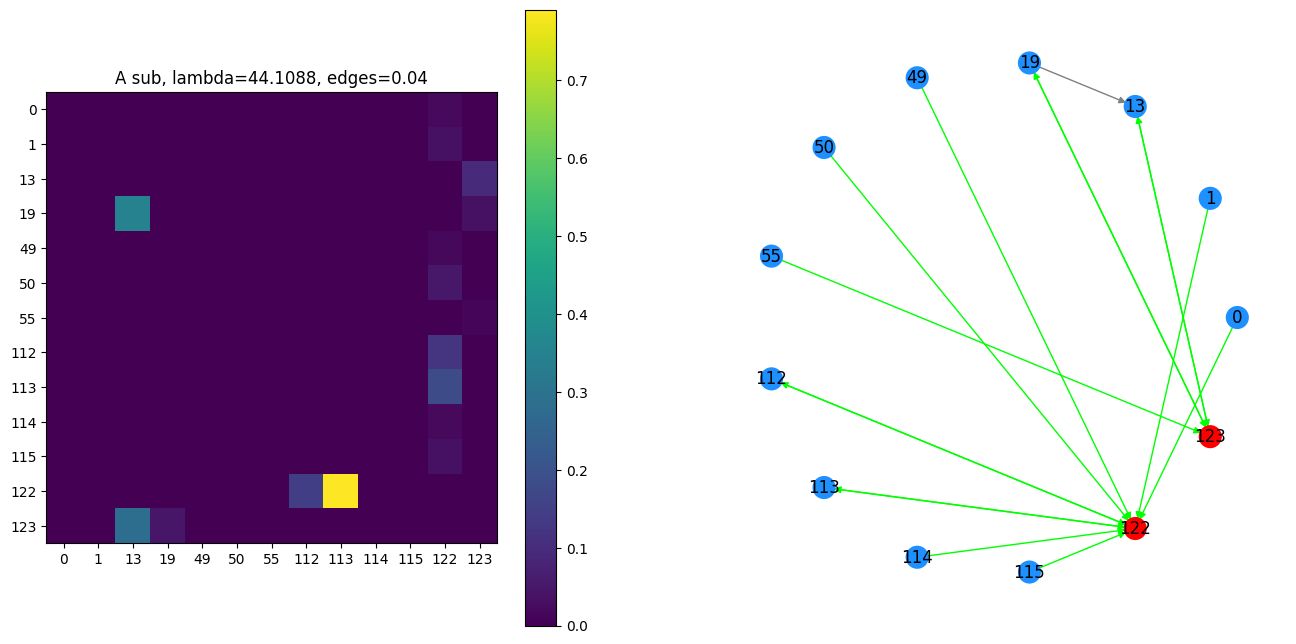

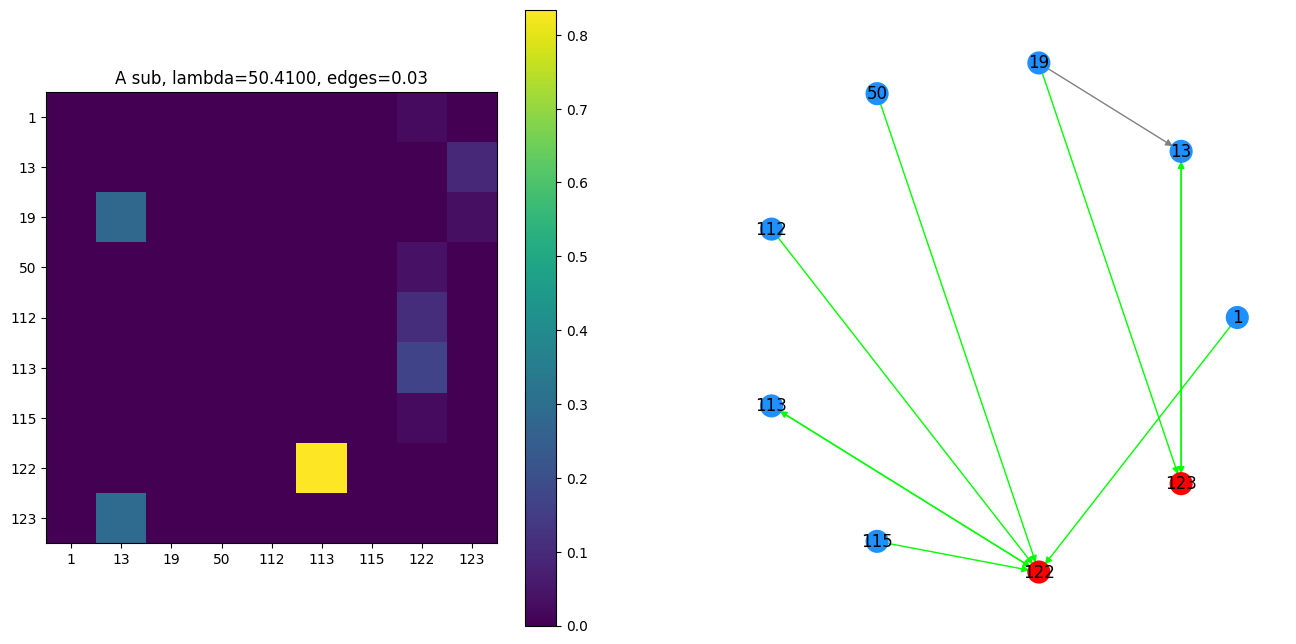

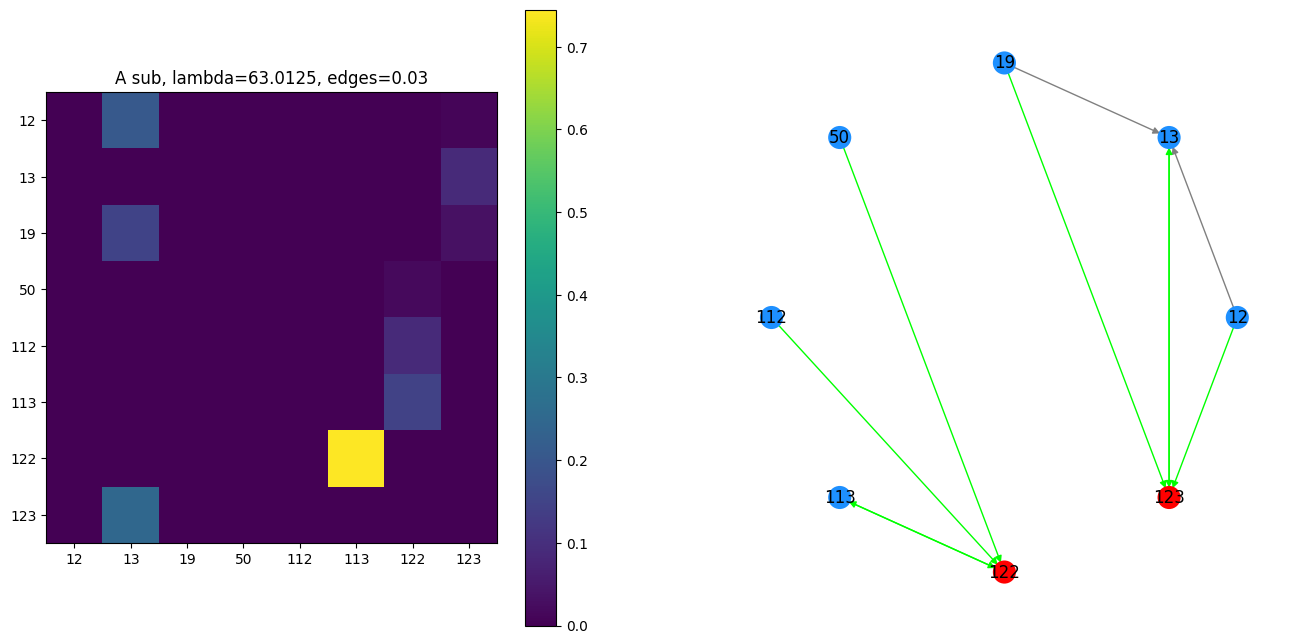

In [7]:
# Plot A
th = 0.01
for i, A_est in enumerate(Dir_sem):
    mult = Mults[i]
    file_name = f'{PREFIX}/sem_dir{mult}_{th}'
    # utils.save_plot_graph(A_est, th, mult*lamb0, file_name=file_name, save=SAVE, directed=True)
    utils.save_plot_subgraph(A_est, th, mult*lamb0, file_name=file_name, save=SAVE, directed=True)

### Threshold = 0.05

- Lamb: 1.5753130434705536  -  Prop. edges above threshold: 0.037
- Lamb: 15.753130434705536  -  Prop. edges above threshold: 0.032
- Lamb: 31.506260869411072  -  Prop. edges above threshold: 0.030
- Lamb: 44.1087652171755  -  Prop. edges above threshold: 0.029
- Lamb: 50.410017391057714  -  Prop. edges above threshold: 0.028
- Lamb: 63.012521738822144  -  Prop. edges above threshold: 0.025


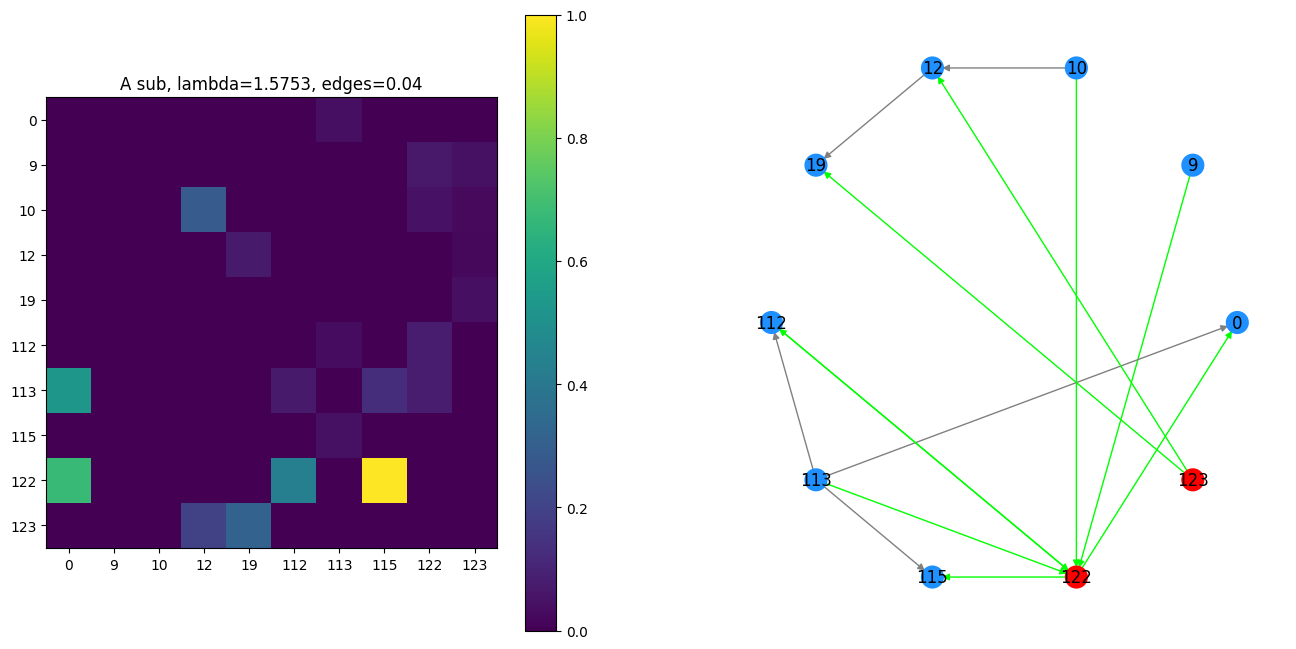

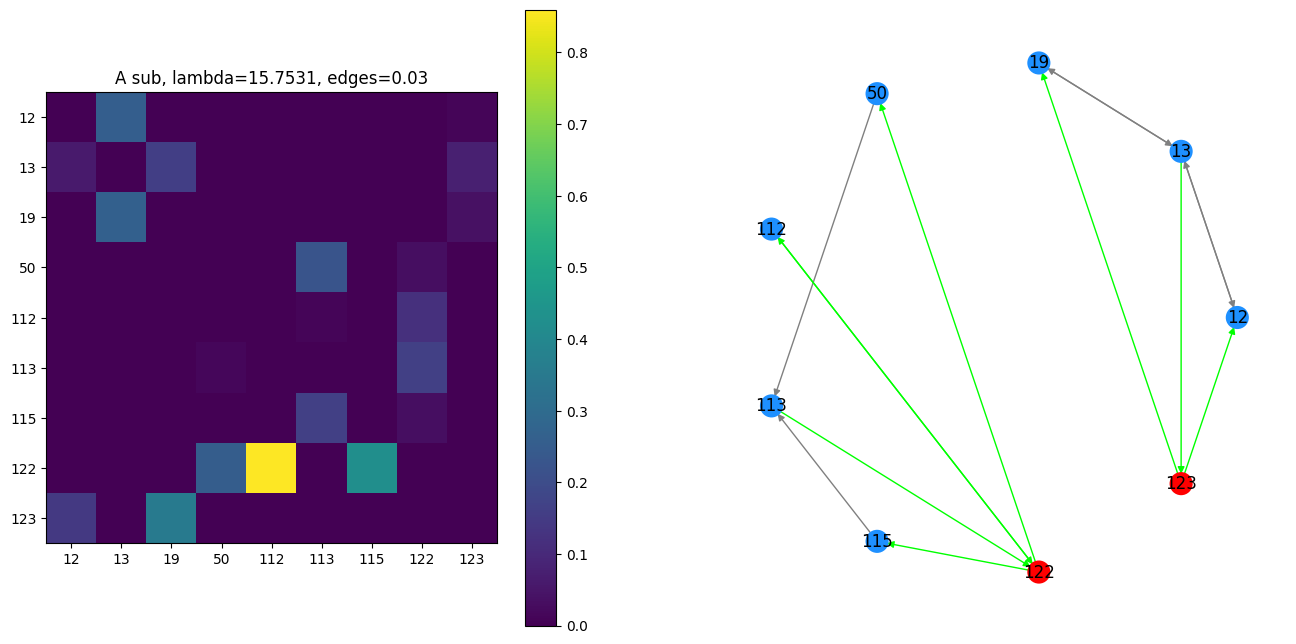

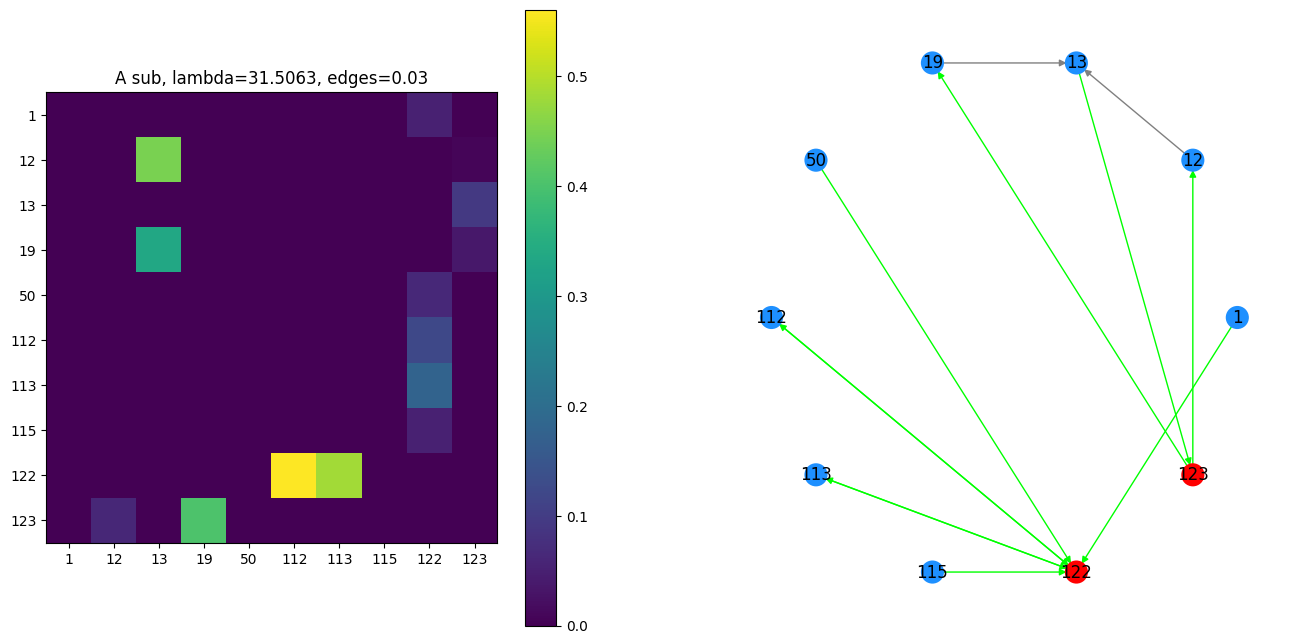

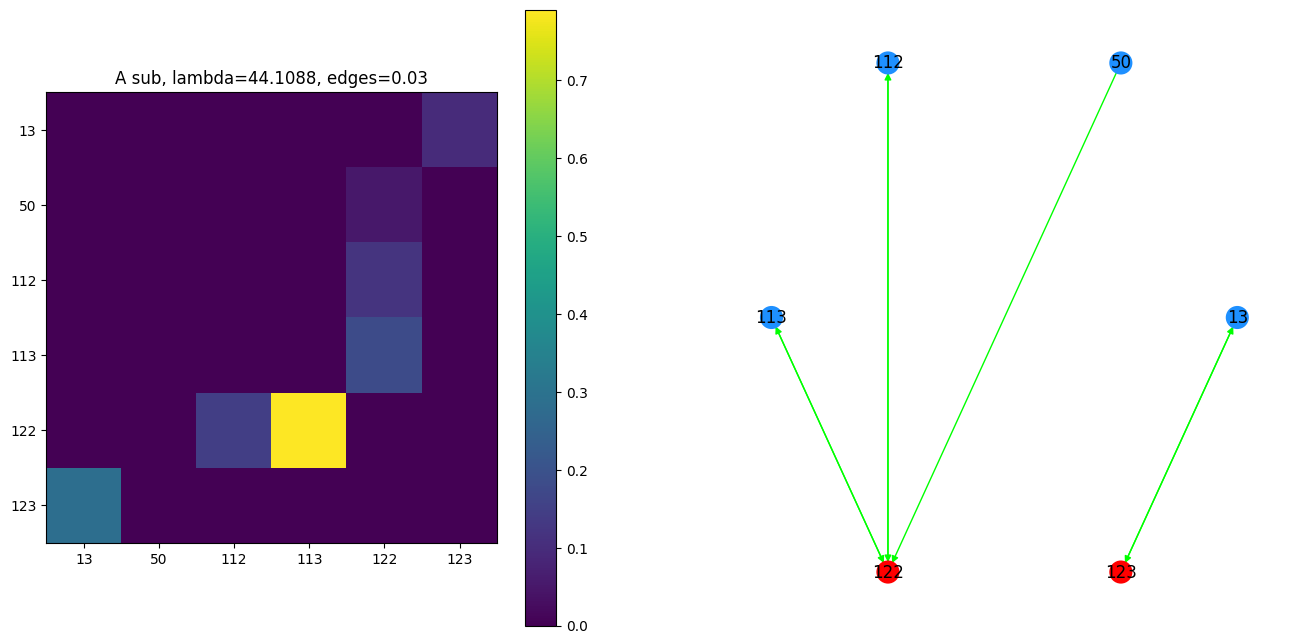

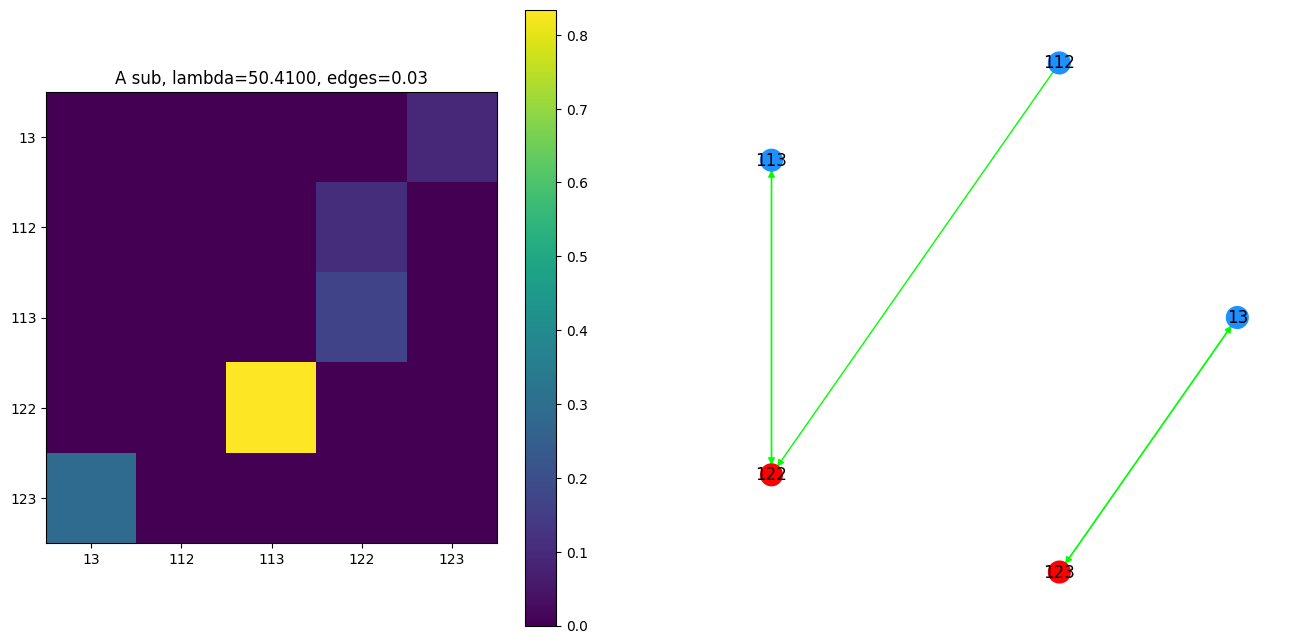

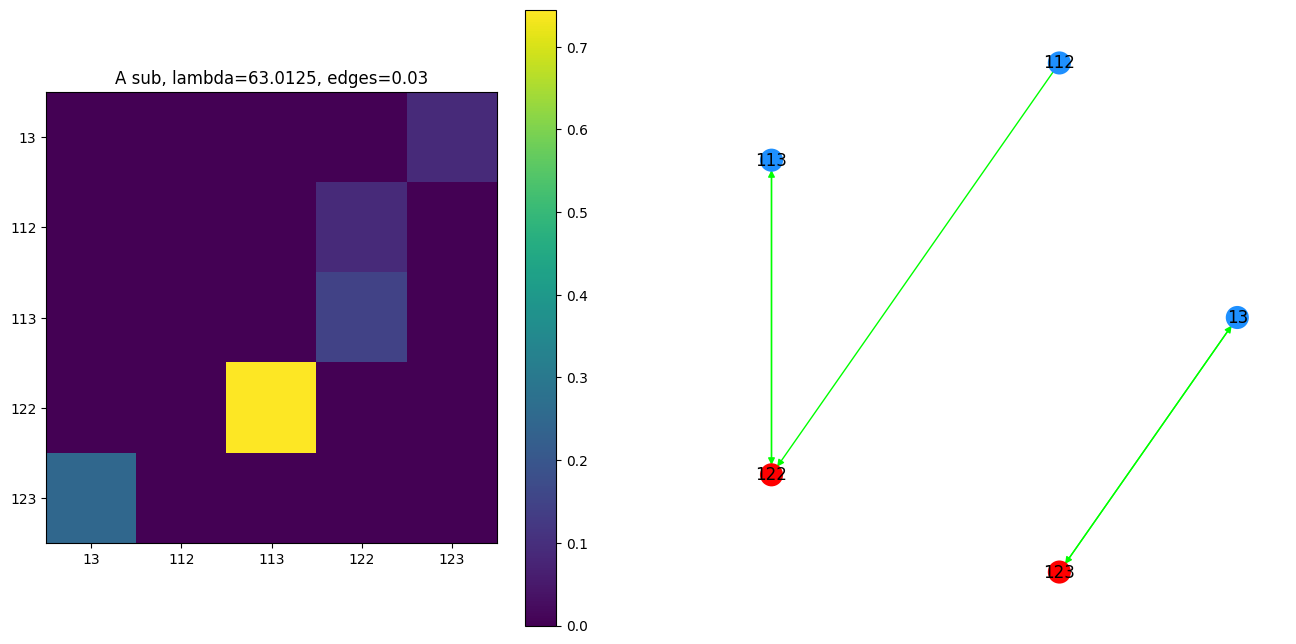

In [8]:
# Plot A
th = 0.05
for i, A_est in enumerate(Dir_sem):
    mult = Mults[i]
    file_name = f'{PREFIX}/sem_dir{mult}_{th}'
    # utils.save_plot_graph(A_est, th, mult*lamb0, file_name=file_name, save=SAVE, directed=True)
    utils.save_plot_subgraph(A_est, th, mult*lamb0, file_name=file_name, directed=True)